# ECG Arrhythmia Classification — Part 2

This notebook builds and compares three machine learning classifiers to detect arrhythmia types from ECG signal segments.

**Dataset:** 3,841 labeled ECG samples × 187 time points, across 5 classes (normal + 4 arrhythmia types)

**Pipeline:**
1. Load and explore the dataset
2. Train/test split (80/20)
3. Tune KNN, Decision Tree, and Random Forest classifiers via 5-fold GridSearchCV
4. Compare accuracy and training time across models

**Tools:** NumPy, Pandas, Matplotlib, scikit-learn

In [1]:
%pip install -U scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from time import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
fs = 125   # sampling frequency (Hz)
Ts = 1/fs  # sampling interval (s)
N = 187    # number of time points per signal
Duration = N * Ts
t = np.linspace(0, Duration - Ts, N)

### Step 1: Load data

In [4]:
X = pd.read_csv('ECG_dataX.csv', header=None)
Y = pd.read_csv('ECG_dataY.csv')

if 'class_label' in Y.columns:
    Y = Y[['class_label']].astype(int)
else:
    Y = Y.iloc[:, [0]].astype(int)

if X.shape[0] != Y.shape[0]:
    min_len = min(X.shape[0], Y.shape[0])
    X = X.iloc[:min_len, :]
    Y = Y.iloc[:min_len, :]

In [5]:
X = X.values

In [6]:
X.shape

(3841, 187)

In [7]:
Y = Y.values

In [8]:
Y.shape

(3841, 1)

In [9]:
Y=Y.reshape(-1)

In [10]:
Y.shape

(3841,)

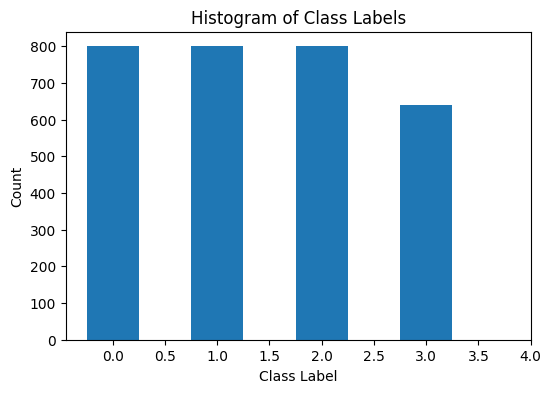

In [11]:
plt.figure(figsize=(6,4))
plt.hist(Y, bins=np.arange(-0.25, 4.25, 0.5))
plt.xticks(np.arange(0.0, 4.5, 0.5))
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Histogram of Class Labels')
plt.show()

From the above histogram, we can see that there are five classes: class-0 to class-4

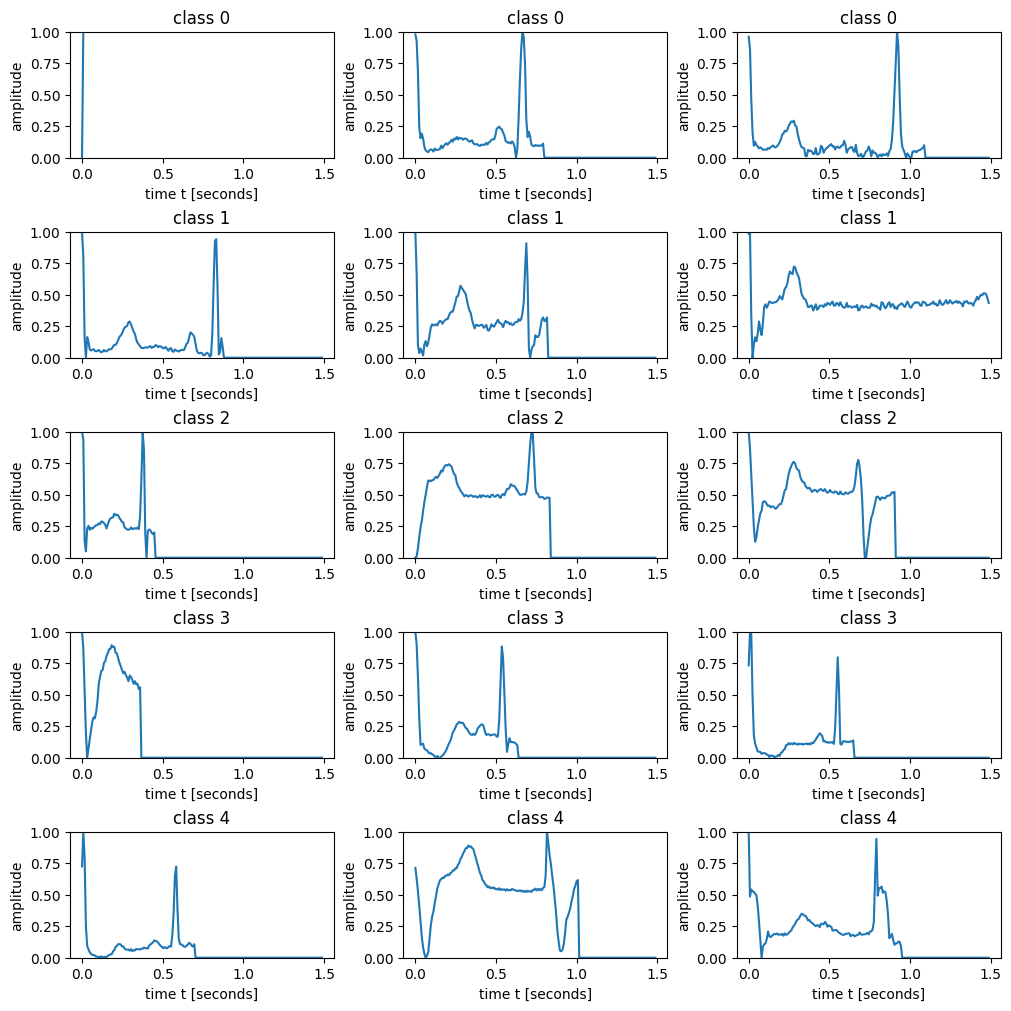

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(10, 10), constrained_layout=True)
classes = np.unique(Y)
fs = 125
Ts = 1/fs
N = X.shape[1]
t = np.linspace(0, (N-1)*Ts, N)

for i, cls in enumerate(classes):
    idx = np.where(Y == cls)[0][:3]
    for j in range(3):
        ax = axes[i, j]
        ax.plot(t, X[idx[j], :])
        ax.set_title(f'class {cls}')
        ax.set_xlabel('time t [seconds]')
        ax.set_ylabel('amplitude')
        ax.set_ylim([0, 1.0])

plt.show()

### Step 2: Split the data into training (80%) and test (20%) sets

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

In [14]:
X_train.shape

(3072, 187)

In [15]:
[X_train.min(), X_train.max()]

[0.0, 186.0]

In [16]:
Y_train.shape

(3072,)

In [17]:
[Y_train.min(), Y_train.max()] #5 classes

[0, 4]

In [18]:
X_test.shape

(769, 187)

In [19]:
[X_test.min(), X_test.max()]

[0.0, 1.0]

In [20]:
Y_test.shape

(769,)

In [21]:
[Y_test.min(), Y_test.max()] #5 classes

[0, 4]

### Step 3A: K-Nearest Neighbors Classifier

In [22]:
n_list = np.arange(1, 101, 5)

In [23]:
param_grid = {'n_neighbors': n_list}

In [24]:
gs_KNN = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

In [25]:
start = time()
gs_KNN.fit(X_train, Y_train)
end = time()
knn_time = end - start
print(f"KNeighborsClassifier: GridSearchCV time cost is {knn_time:.2f} seconds")

KNeighborsClassifier: GridSearchCV time cost is 1.15 seconds


In [26]:
gs_KNN.best_params_

{'n_neighbors': 1}

In [27]:
KNN_model_best = gs_KNN.best_estimator_
KNN_model_best

KNeighborsClassifier(n_neighbors=1)

In [28]:
knn_train_acc = gs_KNN.best_estimator_.score(X_train, Y_train)
print(f"KNeighborsClassifier: training accuracy is {knn_train_acc:.4f}")

KNeighborsClassifier: training accuracy is 1.0000


In [29]:
knn_test_acc = gs_KNN.best_estimator_.score(X_test, Y_test)
print(f"KNeighborsClassifier: test accuracy is {knn_test_acc:.4f}")

KNeighborsClassifier: test accuracy is 0.8283


### Step 3B: Decision Tree Classifier

In [30]:
max_depth_list = np.arange(1, 100, 5)

In [31]:
param_grid = {
    'max_depth': max_depth_list,
    'random_state': [0]
}

In [32]:
gs_DT = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

In [33]:
start = time()
gs_DT.fit(X_train, Y_train)
end = time()
dt_time = end - start
print(f"DecisionTreeClassifier: GridSearchCV time cost is {dt_time:.2f} seconds")

DecisionTreeClassifier: GridSearchCV time cost is 13.58 seconds


In [34]:
gs_DT.best_params_

{'max_depth': 11, 'random_state': 0}

In [35]:
DT_model_best = gs_DT.best_estimator_
DT_model_best

DecisionTreeClassifier(max_depth=11, random_state=0)

In [36]:
dt_train_acc = gs_DT.best_estimator_.score(X_train, Y_train)
print(f"DecisionTreeClassifier: training accuracy is {dt_train_acc:.4f}")

DecisionTreeClassifier: training accuracy is 0.9743


In [37]:
dt_test_acc = gs_DT.best_estimator_.score(X_test, Y_test)
print(f"DecisionTreeClassifier: test accuracy is {dt_test_acc:.4f}")

DecisionTreeClassifier: test accuracy is 0.7815


### Step 3C: Random Forest Classifier

In [38]:
param_grid = {
    'max_depth': max_depth_list,
    'n_estimators': [10],
    'random_state': [0]
}

In [39]:
gs_RF = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

In [40]:
start = time()
gs_RF.fit(X_train, Y_train)
end = time()
rf_time = end - start
print(f"RandomForestClassifier: GridSearchCV time cost is {rf_time:.2f} seconds")

RandomForestClassifier: GridSearchCV time cost is 6.31 seconds


In [41]:
gs_RF.best_params_

{'max_depth': 21, 'n_estimators': 10, 'random_state': 0}

In [42]:
RF_model_best = gs_RF.best_estimator_
RF_model_best

RandomForestClassifier(max_depth=21, n_estimators=10, random_state=0)

In [43]:
rf_train_acc = gs_RF.best_estimator_.score(X_train, Y_train)
print(f"RandomForestClassifier: training accuracy is {rf_train_acc:.4f}")

RandomForestClassifier: training accuracy is 0.9948


In [44]:
rf_test_acc = gs_RF.best_estimator_.score(X_test, Y_test)
print(f"RandomForestClassifier: test accuracy is {rf_test_acc:.4f}")

RandomForestClassifier: test accuracy is 0.8479


### Step 4: Model Comparison

In [45]:
results = {
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'GridSearchCV Time [s]': [knn_time, dt_time, rf_time],
    'Training Accuracy': [knn_train_acc, dt_train_acc, rf_train_acc],
    'Test Accuracy': [knn_test_acc, dt_test_acc, rf_test_acc]
}

df_results = pd.DataFrame(results)
display(df_results)

,Model,GridSearchCV Time [s],Training Accuracy,Test Accuracy
0,KNN,1.146103,1.000000,0.828349
1,Decision Tree,13.576686,0.974284,0.781534
2,Random Forest,6.313871,0.994792,0.847854


### Results Summary

- **Random Forest** achieved the best test accuracy (~84.8%) with a good balance of speed and performance
- **KNN** (k=1) matched RF test accuracy but showed signs of overfitting (100% training accuracy) and is slower at inference
- **Decision Tree** underperformed both ensemble approaches, hitting a ceiling at depth=11
- All models were tuned via 5-fold cross-validation; Random Forest's ensemble averaging provides better generalization than a single tree